# 2026 Super El Niño Watch: Live Thermal Stress Monitoring

**Author:** Frank Velez  
**Date:** May 2026  
**Kernel:** Python (el-nino-2026)  
**Data:** NOAA Coral Reef Watch Regional Virtual Station Feed (5 km, daily)  
**Source:** https://coralreefwatch.noaa.gov/product/vs/data/  
**Cite:** NOAA CRW (1985, updated daily). CoralTemp and Coral Bleaching Heat Stress Products. Accessed May 2026.

---

## Why this project exists

My first marine science portfolio project — *Exploring Coral Bleaching Risk Using NOAA CRW DHW Data* — was a retrospective analysis. I loaded archived data, built a parser to handle the quirks of the Virtual Station file format, and worked through the core metrics: SST anomaly, HotSpot, Degree Heating Weeks, and bleaching alert levels across five reef sites. It was a good way to learn the data and the science simultaneously. But it was a snapshot — a fixed window into the past.

This project is the natural next step. Same data source. Same parser. I included the same five sites from the bleaching analysis, plus two additional Indo-Pacific sites — Palau and West Papua (Raja Ampat) — centered in the El Niño pattern. The difference is that instead of asking what happened during past bleaching events, I want to ask what is happening right now.

The timing matters. In 2024, NOAA confirmed the fourth global coral bleaching event on record — the most spatially extensive ever documented. Many of the sites I tracked in the first project were directly affected. As of early 2026, those reefs have not had adequate time to recover, and a rapidly developing El Niño is now adding new thermal pressure on top of an already elevated baseline. This is not a hypothetical risk scenario. It is an active one. It's honestly part of why
I'm starting this work now after thinking about it for so long.

This notebook re-executes every time it is rendered, pulling fresh data from the NOAA CRW feed. Every figure and value reflects the current year-to-date record, not a cached result. I wanted to practice building something that behaves like a monitoring instrument rather than a finished analysis — the difference between a snapshot and something a reef manager might actually bookmark and check weekly. I also plan to dive several of these sites personally in 2026, which will give me an unusual opportunity to compare what the satellite record shows with what I see on the reef.

---

## The 2026 Super El Niño: background

El Niño is a periodic warming of the central and eastern tropical Pacific, measured by the Oceanic Niño Index (ONI) — the three-month running average SST anomaly in the Niño 3.4 region (5°N–5°S, 170°W–120°W). The standard intensity thresholds are:

| ONI (°C above baseline) | Classification |
|---|---|
| ≥ +0.5 | El Niño — weak |
| ≥ +1.0 | El Niño — moderate |
| ≥ +1.5 | El Niño — strong |
| ≥ +2.0 | **Super El Niño** |

As of April 2026, NOAA's Climate Prediction Center has issued an **El Niño Watch**. Current forecasts from NOAA's CFSv2, the European ECMWF, and the Australian BOM converge on ONI values potentially reaching 3.0 by October–November 2026 — which would make this the strongest El Niño in the modern instrumental record, surpassing the 2015 Super El Niño that peaked at ONI +2.8.

The concern for coral reefs is compound stress. El Niño events warm the tropical Pacific directly, but their effects reach reefs across all ocean basins through atmospheric teleconnections and large-scale circulation changes. The 1997–98 Super El Niño triggered the first documented global bleaching event. The 2015–16 event contributed to the third. What makes 2026 particularly alarming is that reefs are entering this event already weakened — the 2024 bleaching event was still ongoing at many sites when ocean temperatures began their current upward trajectory — and long-term warming has shifted the thermal baseline upward such that each successive event starts from a higher floor.

---

## Why this dataset

The data source here is identical to the first project: the **NOAA Coral Reef Watch Regional Virtual Station** feed.
https://coralreefwatch.noaa.gov/product/vs/data/{station_id}.txt

NOAA retired its legacy 50 km heritage Virtual Stations in April 2020 and replaced them with the current **5 km Regional Virtual Stations** — 219 stations covering all coral reef jurisdictions globally, updated **daily**. Each file contains the full record back to 1985. The file opens with a plain-text metadata header containing each site's **Maximum Monthly Mean (MMM)** baseline — the highest average monthly SST in the historical record for that location — followed by a space-delimited data table with SST, SST anomaly, HotSpot, DHW, and Bleaching Alert Area values.

This is the most operationally current public coral reef thermal stress product available. It is the same data source used by reef managers, NOAA's bleaching alert system, and the primary scientific literature. Alternative products — such as CMEMS satellite SST or OISST — provide comparable raw temperature data but do not include pre-computed DHW and bleaching alert values calibrated to each site's MMM baseline. For monitoring bleaching risk specifically, CRW is the right tool.

For this project I filter to 2026 year-to-date rows only — a focused window on the current season rather than a full historical comparison.

---

## Limitations

**Resolution.** The current CRW product operates at 5 km resolution — a significant improvement over the retired 50 km legacy stations — but a single 5 km pixel still covers an area larger than most individual reef structures. Local bathymetry, currents, and upwelling can produce conditions at the reef scale that diverge from the satellite-derived value. This data is appropriate for regional monitoring; it is not a substitute for in-water measurement.

**Update lag.** This notebook re-executes automatically every morning via a scheduled GitHub Actions 
workflow, pulling fresh data from the NOAA CRW feed and redeploying to the portfolio 
site. Every figure and value you see reflects the most recent available observation — 
no manual intervention required. — the most current publicly available coral bleaching stress product — but there is still an inherent lag between current ocean conditions and published data. The fetch timestamp shown at render time reflects when the data was retrieved.

**Alert levels.** NOAA expanded its bleaching alert system to five levels in December 
2023, with Alert Levels 3–5 capturing extreme stress beyond the historical Level 2 
ceiling. This notebook implements the full five-level system. My first project used 
the legacy two-level model — a reasonable choice for a historical analysis where most 
of the record predates the expanded system — but for a live monitoring page in a 
potential Super El Niño year, the full scale is essential. Sites could experience 
Level 3, 4, or even 5 conditions that a two-level implementation would silently 
misreport as Level 2.

**DHW is a stress proxy, not a bleaching confirmation.** A high DHW value means thermal stress has accumulated beyond the empirical bleaching threshold. It does not mean bleaching has been observed. Actual outcomes depend on species composition, prior stress history, local water quality, and factors that satellite data cannot capture. In-water surveys are the ground truth. This is why we need to continue to fully support NOAAs field operations.

**Personal ground-truth, where available.** I plan to dive several of these sites in 2026. Where I can make my own anecdotical in-water observations. I may note them alongside the satellite record — not as scientific surveys, but as honest anecdotal context from someone who was present.

**I am not a coral ecologist.** I am a data scientist learning this field. Everything 
here is derived from publicly available NOAA products and peer-reviewed literature. 
The real science is owned by NOAA CRW's climatological derivations.

## Study sites

This project monitors **seven reef sites** across two ocean basins — five Caribbean/Atlantic 
sites from the original bleaching project, plus two Indo-Pacific sites added to capture 
the western Pacific warm pool, which historically leads global bleaching events during 
El Niño years.

| Site | Ocean basin | Lat | Lon | Why it's here |
|------|-------------|-----|-----|---------------|
| Florida Keys | Caribbean/Atlantic | 24.55°N | 81.50°W | U.S. reef system; personal dive site; well-documented bleaching history |
| Cayman Islands | Caribbean | 19.30°N | 81.38°W | Personal dive site; isolated mid-Caribbean benchmark |
| Honduras (Bay Islands) | Caribbean | 16.32°N | 86.55°W | Roatán; Mesoamerican Reef; personal dive site |
| ABC Islands (Bonaire) | Caribbean | 12.15°N | 68.28°W | Southern Caribbean; marine park; strong conservation baseline |
| Great Barrier Reef (Central) | Indo-Pacific | 18.00°S | 147.00°E | Central sector (Whitsundays/Townsville region); most studied; severely impacted in 2016 and 2022 bleaching events. NOAA CRW splits the GBR into five station sectors — Central chosen as representative. |
| Palau | Indo-Pacific | 7.50°N | 134.50°E | Western Pacific warm pool; globally significant biodiversity hotspot |
| West Papua (Raja Ampat) | Indo-Pacific | 1.50°S | 132.00°E | Bird's Head Seascape; highest coral diversity on Earth |

Data source: NOAA Coral Reef Watch Virtual Station network, 5 km resolution, v3.1 product 
suite. Each station reports twice-weekly composites of SST, SST Anomaly, HotSpot, and DHW.

## A note on the data pipeline

The first project deliberately kept implementation details in the background —
the focus there was on the science, and a long digression on file parsing
would have broken that flow. But since this project extends the same pipeline
to a live monitoring context, it feels like the right moment to pull back the
curtain a bit.

One of the more satisfying parts of building this project was writing a parser
for NOAA CRW's Virtual Station file format — and I'll be honest: this was
Claude's contribution more than mine. My background is in structured clinical
data — HL7 messages, FHIR resources, JSON pipelines — where the schema is
always explicit, the delimiter is never ambiguous, and a malformed record
throws a validation error before it ever reaches your code. The CRW format is
a different animal entirely.

The files are plain-text, with a free-form prose header that looks like this:
Name:
Florida Keys
...
Averaged Maximum Monthly Mean:
28.36
...
YYYY MM DD SST_MIN SST_MAX SST@90th_HS SSTA@90th_HS 90th_HS>0 DHW_from_90th_HS>1 BAA_7day_max
2000 12 25  27.01   27.45   27.12        -1.24         0.00      0.00               0

No `#` comment markers. No separator line between header and data. Column
names with `@`, `>`, and `%` characters that pandas will misread without
explicit handling. The MMM value — the thermal baseline that the entire alert
system is built on — is sitting two lines below a plain-text label, with no
key-value structure to anchor it.

`parse_crw_header()` handles this by scanning the raw lines one at a time,
looking for two sentinel strings: `"Averaged Maximum Monthly Mean:"` tells it
the next line is the MMM float, and `"YYYY MM DD"` marks the exact line where
the data table begins. That line index gets passed to `pd.read_csv()` via
`StringIO`, so pandas never sees the header at all — it reads only the
structured portion of the file.

The date column requires one more fix. The data table stores date as three
separate integer columns — `YYYY`, `MM`, `DD` — which is common in older
scientific datasets. The safest reconstruction is string concatenation with
`str.zfill(2)` to zero-pad single-digit months and days before passing to
`pd.to_datetime()`. Skipping the zero-padding produces silent failures on
dates like January 5th (`2026-1-5` parses inconsistently across pandas
versions; `2026-01-05` does not).

Finally, `fetch_crw_station()` renames the v3.1 column names —
`DHW_from_90th_HS>1`, `SSTA@90th_HS`, `BAA_7day_max` — to readable aliases
(`dhw`, `sst_anom`, `alert`) and carries the MMM value through as a
site-level column, so every row in the output DataFrame knows its own thermal
baseline. That makes the alert classification logic in `dhw_to_alert()`
self-contained and easy to audit.

The full implementation is in Cell 3 below.

--This parser is carried over directly from the first project with a few small
changes: 

-the cache now stores the raw `.txt` file rather than a parsed CSV
(preserving the original header and MMM value across sessions), and the
`sst_anomaly` column alias from the bleaching project is shortened to
`sst_anom` here for consistency with the status table and plot code.

-Output directories are anchored to the project root rather than using bare
relative paths, so the cache and figure outputs from this project stay
isolated from the bleaching project even if both kernels are running
simultaneously.

In [1]:
# =============================================================================
# Cell 3 — Imports, configuration, and data-fetching infrastructure
# =============================================================================
import os
import pathlib
from io import StringIO
from datetime import datetime, timezone

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Output directories ────────────────────────────────────────────────────────
PROJECT_ROOT = pathlib.Path(__file__).parent if "__file__" in dir() else pathlib.Path().resolve()
CACHE_DIR    = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR   = PROJECT_ROOT / "data" / "processed"
os.makedirs(CACHE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Site configuration ────────────────────────────────────────────────────────
STATIONS = {
    "Florida Keys": {
        "station_id": "florida_keys",
        "lat": 24.55, "lon": -81.50,
        "ocean": "Caribbean/Atlantic",
    },
    "Cayman Islands": {
        "station_id": "cayman_islands",
        "lat": 19.30, "lon": -81.38,
        "ocean": "Caribbean",
    },
    "Honduras (Bay Islands)": {
        "station_id": "honduras",
        "lat": 16.32, "lon": -86.55,
        "ocean": "Caribbean",
    },
    "ABC Islands (Bonaire)": {
        "station_id": "abc_islands",
        "lat": 12.15, "lon": -68.28,
        "ocean": "Caribbean",
    },
    "Great Barrier Reef (Central)": {
        "station_id": "gbr_central",
        "lat": -18.00, "lon": 147.00,
        "ocean": "Indo-Pacific",
    },
    "Palau": {
        "station_id": "palau",
        "lat": 7.50, "lon": 134.50,
        "ocean": "Indo-Pacific",
    },
    "West Papua (Raja Ampat)": {
        "station_id": "west_papua",
        "lat": -1.50, "lon": 132.00,
        "ocean": "Indo-Pacific",
    },
}

CRW_BASE_URL = "https://coralreefwatch.noaa.gov/product/vs/data/{station_id}.txt"

# ── Alert level classifier — NOAA 5-level system (expanded December 2023) ─────
def dhw_to_alert(dhw):
    """
    Map a DHW value (°C-weeks) to a NOAA CRW bleaching alert level string.

    The 5-level system was expanded from the legacy 2-level system in December
    2023 in response to extreme heat stress events that exceeded Level 2 ceilings.
    Levels 3–5 represent conditions with no historical precedent at most sites.
    """
    if pd.isna(dhw) or dhw < 0:
        return "No Stress"
    elif dhw < 4:
        return "Bleaching Watch"
    elif dhw < 8:
        return "Bleaching Warning"
    elif dhw < 12:
        return "Alert Level 1"
    elif dhw < 16:
        return "Alert Level 2"
    elif dhw < 20:
        return "Alert Level 3"
    elif dhw < 24:
        return "Alert Level 4"
    else:
        return "Alert Level 5"

# ── CRW v3.1 parser — proven against the actual file format ──────────────────
def parse_crw_header(lines):
    """
    Extract metadata from the CRW Virtual Station plain-text header block.

    The header has no comment markers — it is free-form text followed by a
    space-delimited data table. We scan for sentinel strings to locate the MMM
    value and the data table start line.
    """
    meta = {}
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped == "Averaged Maximum Monthly Mean:":
            meta["mmm"] = float(lines[i + 1].strip())
        if stripped == "Name:":
            meta["name"] = lines[i + 1].strip()
        if stripped.startswith("YYYY MM DD"):
            meta["data_start_line"] = i
            break
    return meta


def fetch_crw_station(site_name, station_id, force_refresh=False):
    """
    Fetch a NOAA CRW Virtual Station .txt file and return a tidy DataFrame.

    File format: multi-line plain-text header (no # markers), followed by a
    space-delimited data table with columns:
        YYYY MM DD SST_MIN SST_MAX SST@90th_HS SSTA@90th_HS 90th_HS>0
        DHW_from_90th_HS>1 BAA_7day_max

    The header contains the MMM baseline value which we extract and carry
    through as a site-level attribute. Caches to disk to avoid redundant
    fetches within the same session; force_refresh=True always hits NOAA.
    """
    cache_path = os.path.join(CACHE_DIR, f"{station_id}.txt")

    if not force_refresh and os.path.exists(cache_path):
        print(f"  ✓ Loaded from cache: {site_name}")
        with open(cache_path, "r") as f:
            raw_lines = f.readlines()
    else:
        url = CRW_BASE_URL.format(station_id=station_id)
        print(f"  ↓ Fetching live: {site_name}")
        print(f"    {url}")
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        raw_lines = resp.text.splitlines(keepends=True)
        with open(cache_path, "w") as f:
            f.writelines(raw_lines)

    meta = parse_crw_header(raw_lines)
    data_start = meta["data_start_line"]

    data_text = "".join(raw_lines[data_start:])
    df = pd.read_csv(
        StringIO(data_text),
        sep=r"\s+",
        na_values=["-999", "-9999", "-99.0000"],
    )

    df["date"] = pd.to_datetime(
        df["YYYY"].astype(str) + "-" +
        df["MM"].astype(str).str.zfill(2) + "-" +
        df["DD"].astype(str).str.zfill(2)
    )

    df.rename(columns={
        "SST@90th_HS":        "sst",
        "SSTA@90th_HS":       "sst_anom",
        "90th_HS>0":          "hotspot",
        "DHW_from_90th_HS>1": "dhw",
        "BAA_7day_max":       "alert",
    }, inplace=True)

    df["site"] = site_name
    df["mmm"]  = meta.get("mmm", None)

    keep = ["date", "sst", "sst_anom", "hotspot", "dhw", "alert", "site", "mmm"]
    df = df[[c for c in keep if c in df.columns]]
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


def fetch_2026_ytd(site_name, station_id):
    """Fetch full station history, filter to 2026 YTD, always hits NOAA live."""
    df = fetch_crw_station(site_name, station_id, force_refresh=True)
    if df is None:
        return None
    mask = df["date"].dt.year == 2026
    sub = df[mask].copy()
    return sub if len(sub) > 0 else None


print("✓ Cell 3 complete — imports, STATIONS, and helpers loaded.")
print(f"  Sites configured: {len(STATIONS)}")
for name, cfg in STATIONS.items():
    print(f"  • {name} ({cfg['station_id']})")

✓ Cell 3 complete — imports, STATIONS, and helpers loaded.
  Sites configured: 7
  • Florida Keys (florida_keys)
  • Cayman Islands (cayman_islands)
  • Honduras (Bay Islands) (honduras)
  • ABC Islands (Bonaire) (abc_islands)
  • Great Barrier Reef (Central) (gbr_central)
  • Palau (palau)
  • West Papua (Raja Ampat) (west_papua)


In [2]:
# =============================================================================
# Cell 4 — Fetch 2026 YTD data for all seven sites
# =============================================================================
fetch_stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
print(f"Fetching 2026 YTD data from NOAA CRW Virtual Stations...")
print(f"Timestamp: {fetch_stamp}\n")

site_data   = {}   # name → DataFrame (successful fetches)
site_errors = []   # names that failed

for name, cfg in STATIONS.items():
    try:
        df = fetch_2026_ytd(name, cfg["station_id"])
        if df is not None and len(df) > 0:
            site_data[name] = df
            last = df.iloc[-1]
            print(f"    ✓ {len(df):>3} rows | "
                  f"{df['date'].min().date()} → {df['date'].max().date()} | "
                  f"MMM: {last['mmm']}°C | "
                  f"Latest DHW: {last['dhw']:.1f} °C-wk")
        else:
            print(f"    ⚠ No 2026 data returned for {name}")
            site_errors.append(name)
    except Exception as e:
        print(f"    ✗ FAILED {name}: {e}")
        site_errors.append(name)

print(f"\n{'─'*60}")
print(f"✓ Fetched: {len(site_data)}/{len(STATIONS)} sites")
if site_errors:
    print(f"✗ Failed:  {site_errors}")

Fetching 2026 YTD data from NOAA CRW Virtual Stations...
Timestamp: 2026-05-13 17:57 UTC

  ↓ Fetching live: Florida Keys
    https://coralreefwatch.noaa.gov/product/vs/data/florida_keys.txt
    ✓ 131 rows | 2026-01-01 → 2026-05-11 | MMM: 29.6264°C | Latest DHW: 0.0 °C-wk
  ↓ Fetching live: Cayman Islands
    https://coralreefwatch.noaa.gov/product/vs/data/cayman_islands.txt
    ✓ 131 rows | 2026-01-01 → 2026-05-11 | MMM: 29.3925°C | Latest DHW: 0.0 °C-wk
  ↓ Fetching live: Honduras (Bay Islands)
    https://coralreefwatch.noaa.gov/product/vs/data/honduras.txt
    ✓ 131 rows | 2026-01-01 → 2026-05-11 | MMM: 28.87°C | Latest DHW: 0.0 °C-wk
  ↓ Fetching live: ABC Islands (Bonaire)
    https://coralreefwatch.noaa.gov/product/vs/data/abc_islands.txt
    ✓ 131 rows | 2026-01-01 → 2026-05-11 | MMM: 28.0193°C | Latest DHW: 0.0 °C-wk
  ↓ Fetching live: Great Barrier Reef (Central)
    https://coralreefwatch.noaa.gov/product/vs/data/gbr_central.txt
    ✓ 131 rows | 2026-01-01 → 2026-05-11 | MMM

In [3]:
# =============================================================================
# Cell 5 — Current thermal stress status table
# =============================================================================
rows = []
for name, df in site_data.items():
    last = df.iloc[-1]
    alert = dhw_to_alert(last["dhw"])
    rows.append({
        "Site":              name,
        "Ocean basin":       STATIONS[name]["ocean"],
        "Latest date":       last["date"].strftime("%Y-%m-%d"),
        "SST (°C)":          f"{last['sst']:.2f}"   if pd.notna(last["sst"])      else "—",
        "SST anomaly (°C)":  f"{last['sst_anom']:+.2f}" if pd.notna(last["sst_anom"]) else "—",
        "DHW (°C-wk)":       f"{last['dhw']:.1f}"   if pd.notna(last["dhw"])      else "—",
        "Alert level":       alert,
    })

for name in site_errors:
    rows.append({
        "Site":             name,
        "Ocean basin":      STATIONS[name]["ocean"],
        "Latest date":      "—",
        "SST (°C)":         "—",
        "SST anomaly (°C)": "—",
        "DHW (°C-wk)":      "—",
        "Alert level":      "Data unavailable",
    })

status_df = pd.DataFrame(rows)

def color_alert(val):
    color_map = {
        "No Stress":         "background-color: #BBDEFB; color: #0D47A1",
        "Bleaching Watch":   "background-color: #FFF9C4; color: #F57F17",
        "Bleaching Warning": "background-color: #FFE0B2; color: #E65100",
        "Alert Level 1":     "background-color: #FFCDD2; color: #B71C1C",
        "Alert Level 2":     "background-color: #E1BEE7; color: #4A148C",
        "Alert Level 3":     "background-color: #880E4F; color: #FFFFFF",
        "Alert Level 4":     "background-color: #4A0000; color: #FFFFFF",
        "Alert Level 5":     "background-color: #000000; color: #FFFFFF",
        "Data unavailable":  "background-color: #EEEEEE; color: #757575",
    }
    return color_map.get(val, "")

styled = (
    status_df.style
    .map(color_alert, subset=["Alert level"])  # pandas 2.x: applymap → map
    .set_properties(**{"text-align": "center"}, subset=status_df.columns[1:])
    .set_properties(**{"font-weight": "bold"}, subset=["Site", "Alert level"])
    .hide(axis="index")
)

print(f"Status as of {fetch_stamp}")
styled

Status as of 2026-05-13 17:57 UTC


Site,Ocean basin,Latest date,SST (°C),SST anomaly (°C),DHW (°C-wk),Alert level
Florida Keys,Caribbean/Atlantic,2026-05-11,29.54,+3.11,0.0,Bleaching Watch
Cayman Islands,Caribbean,2026-05-11,28.81,+1.20,0.0,Bleaching Watch
Honduras (Bay Islands),Caribbean,2026-05-11,29.27,+1.42,0.0,Bleaching Watch
ABC Islands (Bonaire),Caribbean,2026-05-11,27.45,+1.00,0.0,Bleaching Watch
Great Barrier Reef (Central),Indo-Pacific,2026-05-11,25.88,+0.56,1.1,Bleaching Watch
Palau,Indo-Pacific,2026-05-11,30.12,+0.97,0.0,Bleaching Watch
West Papua (Raja Ampat),Indo-Pacific,2026-05-11,30.48,+1.42,1.1,Bleaching Watch


As of mid-May 2026, all seven sites are at **Bleaching Watch** — temperatures 
are already above their historical summer maximums at every location, but 
heat stress has not yet accumulated long enough to trigger a Warning. The 
Florida Keys anomaly of +3.11°C is particularly notable: it is the highest 
in the table and nearly three times the +1°C bleaching threshold. DHW there 
remains at zero only because the anomaly is recent. If conditions hold through 
June and July, the Keys will be the first site to watch.

The two Indo-Pacific sites carry small residual DHW values from the Southern 
Hemisphere summer that just ended. Those will likely decay toward zero over 
the next few weeks unless new heat stress develops.

✓ DHW panel saved to /Users/renatus/code/el-nino-watch-2026/data/processed/dhw_panel_2026.png


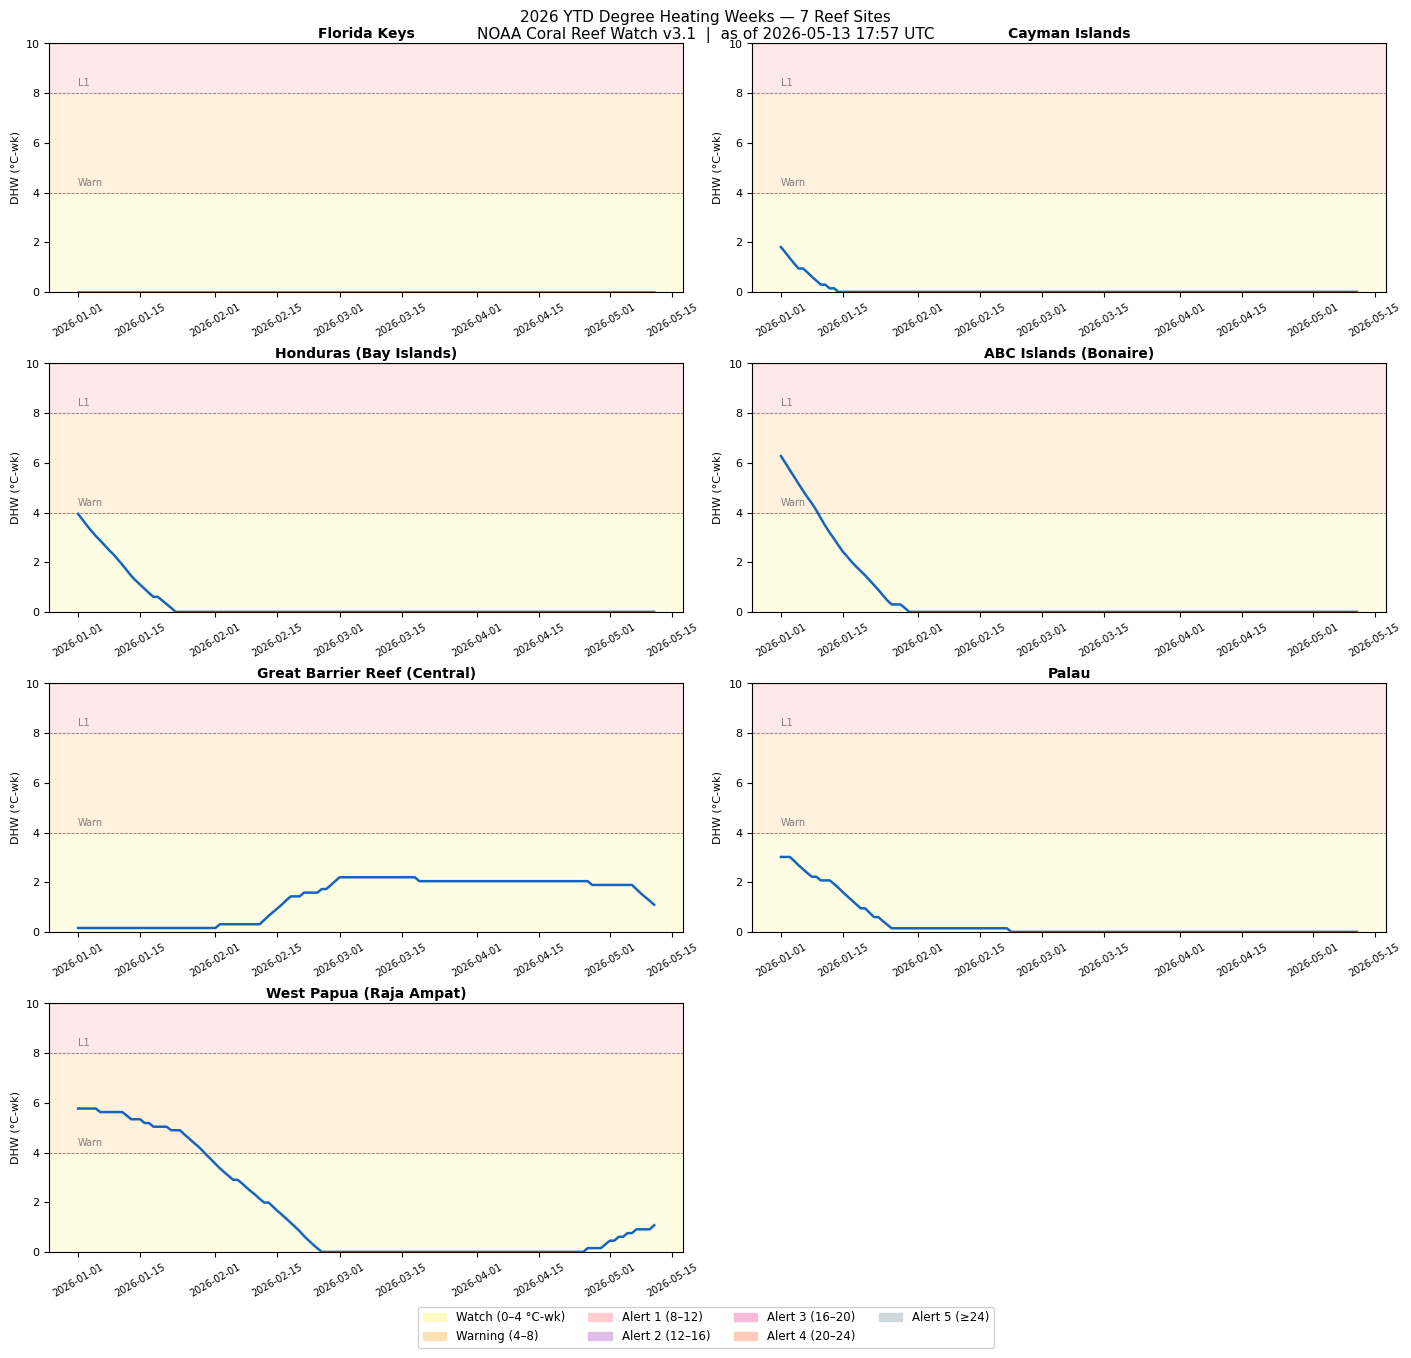

In [4]:
# =============================================================================
# Cell 6 — DHW time series panel plot (one subplot per site)
# =============================================================================
sites_to_plot = list(site_data.keys())
n = len(sites_to_plot)

if n == 0:
    print("No data to plot.")
else:
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2),
                             sharey=False, constrained_layout=True)
    axes_flat = axes.flat if n > 1 else [axes]

    alert_bands = [
        (0,  4,  "#FFF9C4", "Watch"),
        (4,  8,  "#FFE0B2", "Warning"),
        (8,  12, "#FFCDD2", "Alert 1"),
        (12, 16, "#E1BEE7", "Alert 2"),
        (16, 20, "#F8BBD9", "Alert 3"),
        (20, 24, "#FFCCBC", "Alert 4"),
    ]

    for ax, name in zip(axes_flat, sites_to_plot):
        df = site_data[name]
        ax.plot(df["date"], df["dhw"], color="#1565C0", linewidth=1.8, zorder=3)

        ymax = max(df["dhw"].max() * 1.15, 10)
        for ylo, yhi, color, _ in alert_bands:
            ax.axhspan(ylo, min(yhi, ymax), color=color, alpha=0.45, zorder=0)
        if df["dhw"].max() >= 24:
            ax.axhspan(24, ymax, color="#CFD8DC", alpha=0.35, zorder=0)

        for thresh, label in [(4, "Warn"), (8, "L1"), (12, "L2"),
                               (16, "L3"), (20, "L4"), (24, "L5")]:
            if thresh <= ymax:
                ax.axhline(thresh, color="gray", linewidth=0.6,
                           linestyle="--", zorder=2)
                ax.text(df["date"].min(), thresh + 0.2, label,
                        fontsize=7, color="gray", va="bottom")

        ax.set_title(name, fontsize=10, fontweight="bold", pad=4)
        ax.set_xlabel("")
        ax.set_ylabel("DHW (°C-wk)", fontsize=8)
        ax.set_ylim(0, ymax)
        ax.tick_params(axis="x", labelsize=7, rotation=30)
        ax.tick_params(axis="y", labelsize=8)

    # Hide unused subplots — outside the per-site loop
    for i in range(n, nrows * ncols):
        axes.flat[i].set_visible(False)

    # Shared legend
    legend_handles = [
        mpatches.Patch(color="#FFF9C4", label="Watch (0–4 °C-wk)"),
        mpatches.Patch(color="#FFE0B2", label="Warning (4–8)"),
        mpatches.Patch(color="#FFCDD2", label="Alert 1 (8–12)"),
        mpatches.Patch(color="#E1BEE7", label="Alert 2 (12–16)"),
        mpatches.Patch(color="#F8BBD9", label="Alert 3 (16–20)"),
        mpatches.Patch(color="#FFCCBC", label="Alert 4 (20–24)"),
        mpatches.Patch(color="#CFD8DC", label="Alert 5 (≥24)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.04), fontsize=8.5, framealpha=0.9)

    fig.suptitle(f"2026 YTD Degree Heating Weeks — 7 Reef Sites\n"
                 f"NOAA Coral Reef Watch v3.1  |  as of {fetch_stamp}",
                 fontsize=11, y=1.01)

    plt.savefig(os.path.join(OUTPUT_DIR, "dhw_panel_2026.png"),
                dpi=150, bbox_inches="tight")
    print(f"✓ DHW panel saved to {OUTPUT_DIR}/dhw_panel_2026.png")
    plt.show()

✓ SST anomaly bar chart saved to /Users/renatus/code/el-nino-watch-2026/data/processed/sst_anom_bar_2026.png


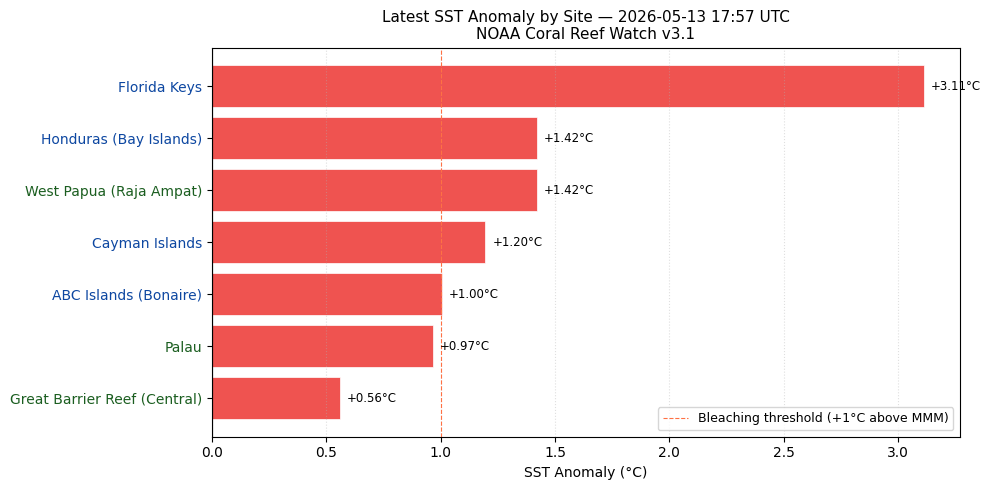

In [5]:
# =============================================================================
# Cell 7 — Latest SST anomaly comparison bar chart
# =============================================================================
if len(site_data) == 0:
    print("No data to plot.")
else:
    latest_rows = []
    for name, df in site_data.items():
        last = df.iloc[-1]
        latest_rows.append({
            "site":     name,
            "ocean":    STATIONS[name]["ocean"],
            "sst_anom": last["sst_anom"],
            "date":     last["date"].strftime("%Y-%m-%d"),
        })
    latest_df = pd.DataFrame(latest_rows).sort_values("sst_anom", ascending=True)

    colors = ["#EF5350" if v >= 0 else "#42A5F5"
              for v in latest_df["sst_anom"]]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(latest_df["site"], latest_df["sst_anom"],
                   color=colors, edgecolor="white", linewidth=0.5)

    ax.axvline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axvline(1, color="#FF7043", linewidth=0.8, linestyle="--",
               label="Bleaching threshold (+1°C above MMM)")

    for bar, val in zip(bars, latest_df["sst_anom"]):
        offset = 0.03 if val >= 0 else -0.03
        ha = "left" if val >= 0 else "right"
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f"{val:+.2f}°C", va="center", ha=ha, fontsize=8.5)

    ax.set_xlabel("SST Anomaly (°C)", fontsize=10)
    ax.set_title(f"Latest SST Anomaly by Site — {fetch_stamp}\n"
                 f"NOAA Coral Reef Watch v3.1",
                 fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="x", linestyle=":", alpha=0.4)

    # Color-code y-axis labels by ocean basin
    for label in ax.get_yticklabels():
        name = label.get_text()
        if name in STATIONS:
            ocean = STATIONS[name]["ocean"]
            label.set_color("#1B5E20" if "Indo" in ocean else "#0D47A1")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sst_anom_bar_2026.png"),
                dpi=150, bbox_inches="tight")
    print(f"✓ SST anomaly bar chart saved to {OUTPUT_DIR}/sst_anom_bar_2026.png")
    plt.show()

## El Niño progression and reef thermal stress

The anomalies in the chart above are not random variation — this project is
called "2026 Super El Niño Watch" for a reason. The working hypothesis from
the start has been that an active or developing El Niño event is driving
elevated SSTs across our monitoring sites. What we haven't done yet is show
that directly.

It's worth being explicit about this: starting with a hypothesis and then
looking for supporting evidence is not the same as falsifying it. The honest
next step is to bring in an independent measure of El Niño progression and ask
whether the pattern we're seeing at the reefs actually tracks it — and whether
it doesn't track it anywhere, which would be equally informative.

This is where the Oceanic Niño Index (ONI) comes in. The ONI is NOAA's
official metric for declaring and tracking El Niño and La Niña events. It
measures SST anomalies in the Niño 3.4 region — a patch of the central
equatorial Pacific that acts as the primary engine of ENSO variability. When
the ONI stays at or above +0.5°C for five consecutive overlapping 3-month
periods, NOAA officially declares an El Niño. I'm pretty sure I learned something
like this in high school earth science — but I checked.

The connection to reef bleaching is well established in the Indo-Pacific: El
Niño suppresses upwelling, warms surface waters across the western Pacific,
and drives the kind of prolonged thermal stress that accumulates into dangerous
DHW values. The relationship in the Caribbean is more indirect — El Niño
alters atmospheric circulation patterns and suppresses Atlantic hurricane
activity in ways that can allow heat to build in Caribbean surface waters —
but the signal is still present in the historical record.

By overlaying the ONI against mean DHW across our seven sites, we can ask a
simple but important question: does the El Niño signal correlate with what
we're seeing at the reefs? If it does, that strengthens the case that what
we're monitoring is not local noise but part of a basin-scale thermal event.To be clear: the physical mechanism linking El Niño to coral bleaching is not
in question, and I want to be honest about how I know that — I'm not a marine
scientist. It just seemed like a no-brainer from the data, so I did a
literature search and read some abstracts. It turns out the causal chain is
well established and has been for decades.

The 1998 global bleaching event, which killed an estimated 16% of the world's
coral reefs, coincided with one of the strongest El Niño events on record. The
mechanism is documented: El Niño suppresses equatorial upwelling, reduces
cloud cover, and drives anomalously warm surface waters across the Indo-Pacific
warm pool, creating conditions for prolonged thermal stress to accumulate into
dangerous DHW values. Hoegh-Guldberg (1999) formalized much of this.
Hughes et al. (2017, 2018) documented it in devastating detail for the Great
Barrier Reef during the 2016 event — back-to-back mass bleaching on a scale
that had no historical precedent. The Caribbean connection is less direct
mechanistically but is also documented; Eakin et al. (2010) covers the 2005
Caribbean bleaching event, which was the worst on record at the time.

So the broad causal story is not what my economist wife would push back on.
What is *not* established in our specific dataset is the quantitative
relationship between ONI values and DHW at these seven particular sites in
2026. That's the narrower claim — and she'd be right to push back on it.

I'll be transparent about the limitation here: correlation between ONI and
mean DHW across a mixed set of Caribbean and Indo-Pacific sites is suggestive
at best. I'm married to an economist, and I would be remiss if I didn't
address the correlation-causation issue at hand.

She would probably start by pointing out that what we have here is a
two-variable time series plot with no controls, no lag structure, and a sample
size of one El Niño event. That's not a finding — that's a hypothesis. To do
this properly she'd suggest something along the lines of:

- **Distributed lag models** — the effect of ONI on reef SST anomalies isn't
  instantaneous; it propagates over weeks to months depending on the basin.
  A proper analysis would test a range of lags (4, 8, 12 weeks) and report
  which lag structure best fits the data at each site.
- **Basin-separated regressions** — pooling Caribbean and Indo-Pacific sites
  into a single mean DHW obscures the fact that ENSO affects each basin
  through different mechanisms and on different timescales. She'd run them
  separately.
- **Robustness checks** — does the correlation hold if you drop the Florida
  Keys outlier? Does it hold across previous El Niño years in the historical
  record? If the relationship falls apart when you remove one site or one
  year, it isn't robust.
- **Granger causality** — does ONI actually help predict future DHW values,
  or are they just moving together for unrelated reasons? A Granger test
  wouldn't establish physical causation but would at least tell us whether
  the ONI signal has predictive value for reef stress.

This came up at dinner. She's right. This is a monitoring dashboard, not a
causal study, and the chart below should be read as a visual sanity check
against a known climate driver — not as evidence of a causal relationship.
A rigorous treatment is on the list for a future version of this project.

To be clear: the physical mechanism linking El Niño to coral bleaching is not
in question, and I want to be honest about how I know that — I'm not a marine
scientist. It just seemed like a no-brainer from the data, so I did a
literature search and read some abstracts. It turns out the causal chain is
well established and has been for decades.

The 1998 global bleaching event, which killed an estimated 16% of the world's
coral reefs, coincided with one of the strongest El Niño events on record. The
mechanism is documented: El Niño suppresses equatorial upwelling, reduces
cloud cover, and drives anomalously warm surface waters across the Indo-Pacific
warm pool, creating conditions for prolonged thermal stress to accumulate into
dangerous DHW values. Hoegh-Guldberg (1999) formalized much of this.
Hughes et al. (2017, 2018) documented it in devastating detail for the Great
Barrier Reef during the 2016 event — back-to-back mass bleaching on a scale
that had no historical precedent. The Caribbean connection is less direct
mechanistically but is also documented; Eakin et al. (2010) covers the 2005
Caribbean bleaching event, which was the worst on record at the time.

So the broad causal story is not what my economist wife would push back on.
What is *not* established in our specific dataset is the quantitative
relationship between ONI values and DHW at these seven particular sites in
2026. That's the narrower claim — and she'd be right to push back on it.

One more honest note: I started this project because I dive these reefs and
care about what happens to them. The Florida Keys anomaly of +3.11°C, West
Papua already carrying DHW, all seven sites at Bleaching Watch before summer
even starts in the Northern Hemisphere — I know what that pattern looked like
in 2023 and 2016. I'm prepared for some serious heartbreak this summer. I hope
I'm wrong.

In [6]:
# =============================================================================
# Cell 8 — ONI vs mean DHW: El Niño progression and reef thermal stress
# =============================================================================

ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"

def fetch_oni():
    """
    Fetch NOAA CPC Oceanic Nino Index (ONI) data.

    Format: fixed-width text, columns SEAS YR TOTAL ANOM
    SEAS is a 3-month season label (e.g. JFM, FMA, ..., DJF).
    ANOM is the SST anomaly in the Nino 3.4 region in degrees C.
    We assign each season to the middle month for plotting.
    """
    SEASON_TO_MONTH = {
        "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
        "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
        "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
    }

    resp = requests.get(ONI_URL, timeout=30)
    resp.raise_for_status()

    rows = []
    for line in resp.text.splitlines():
        parts = line.split()
        if len(parts) < 4 or parts[0] == "SEAS":
            continue
        try:
            seas  = parts[0]
            yr    = int(parts[1])
            anom  = float(parts[3])
            month = SEASON_TO_MONTH.get(seas)
            if month is None:
                continue
            rows.append({"year": yr, "month": month, "oni": anom})
        except ValueError:
            continue

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(
        df["year"].astype(str) + "-" +
        df["month"].astype(str).str.zfill(2) + "-01"
    )
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# Fetch ONI and filter to 2026 YTD
print("Fetching ONI data from NOAA CPC...")
oni_df = fetch_oni()
oni_2026 = oni_df[oni_df["date"].dt.year == 2026].copy()

if len(oni_2026) == 0:
    # ONI is published with a lag of 1-2 months -- fall back to trailing 12
    print("  No 2026 ONI data yet -- using trailing 12 months")
    oni_2026 = oni_df.tail(12).copy()

print(f"  ONI periods: {len(oni_2026)} | "
      f"{oni_2026['date'].min().date()} -> {oni_2026['date'].max().date()} | "
      f"Latest ONI: {oni_2026['oni'].iloc[-1]:+.2f} degrees C")

# Compute mean DHW by ocean basin
caribbean_sites = [n for n, cfg in STATIONS.items() if "Caribbean" in cfg["ocean"]]
indopacific_sites = [n for n, cfg in STATIONS.items() if "Indo-Pacific" in cfg["ocean"]]

def basin_mean_dhw(site_list):
    frames = [site_data[n] for n in site_list if n in site_data]
    if not frames:
        return pd.DataFrame(columns=["date", "mean_dhw"])
    return (
        pd.concat(frames)
        .groupby("date")["dhw"]
        .mean()
        .reset_index()
        .rename(columns={"dhw": "mean_dhw"})
        .query("date.dt.year == 2026")
        .copy()
    )

caribbean_dhw   = basin_mean_dhw(caribbean_sites)
indopacific_dhw = basin_mean_dhw(indopacific_sites)

print(f"  Caribbean sites: {caribbean_sites}")
print(f"  Indo-Pacific sites: {indopacific_sites}")

Fetching ONI data from NOAA CPC...
  ONI periods: 3 | 2026-01-01 -> 2026-03-01 | Latest ONI: +0.11 degrees C
  Caribbean sites: ['Florida Keys', 'Cayman Islands', 'Honduras (Bay Islands)', 'ABC Islands (Bonaire)']
  Indo-Pacific sites: ['Great Barrier Reef (Central)', 'Palau', 'West Papua (Raja Ampat)']


ONI vs DHW chart saved to /Users/renatus/code/el-nino-watch-2026/data/processed/oni_vs_dhw_2026.png


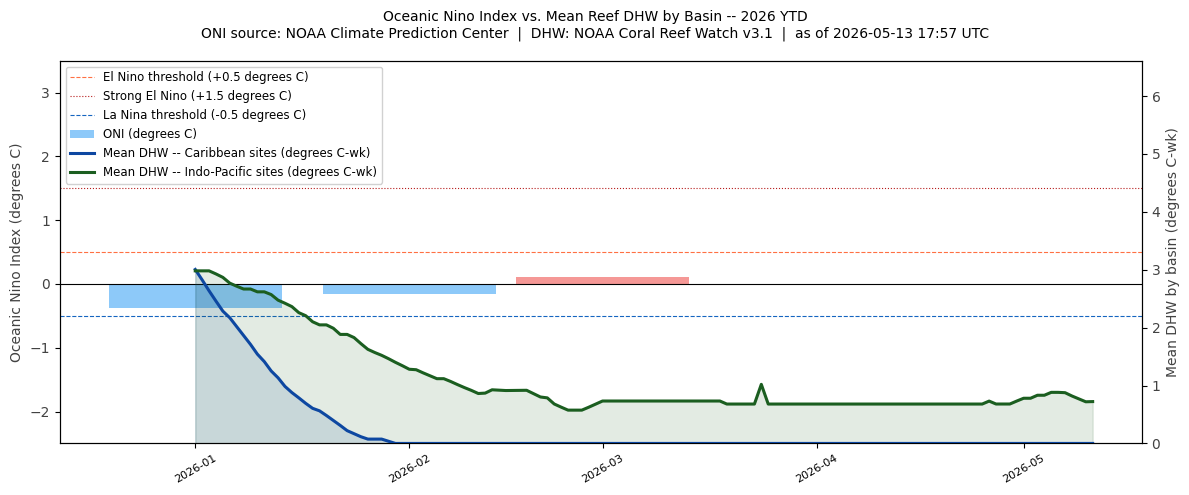

In [7]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

# ONI bars
bar_colors = ["#EF5350" if v >= 0 else "#42A5F5" for v in oni_2026["oni"]]
ax1.bar(oni_2026["date"], oni_2026["oni"], width=25,
        color=bar_colors, alpha=0.6, zorder=2, label="ONI (degrees C)")
ax1.axhline(0,    color="black",   linewidth=0.8, linestyle="-")
ax1.axhline(0.5,  color="#FF7043", linewidth=0.8, linestyle="--",
            label="El Nino threshold (+0.5 degrees C)")
ax1.axhline(1.5,  color="#B71C1C", linewidth=0.8, linestyle=":",
            label="Strong El Nino (+1.5 degrees C)")
ax1.axhline(-0.5, color="#1565C0", linewidth=0.8, linestyle="--",
            label="La Nina threshold (-0.5 degrees C)")
ax1.set_ylabel("Oceanic Nino Index (degrees C)", fontsize=10, color="#424242")
ax1.tick_params(axis="y", labelcolor="#424242")
ax1.set_ylim(-2.5, 3.5)

# Second axis for DHW
ax2 = ax1.twinx()

# Caribbean mean DHW
ax2.plot(caribbean_dhw["date"], caribbean_dhw["mean_dhw"],
         color="#0D47A1", linewidth=2.2, zorder=3,
         label="Mean DHW -- Caribbean sites (degrees C-wk)")
ax2.fill_between(caribbean_dhw["date"], caribbean_dhw["mean_dhw"],
                 alpha=0.12, color="#0D47A1")

# Indo-Pacific mean DHW
ax2.plot(indopacific_dhw["date"], indopacific_dhw["mean_dhw"],
         color="#1B5E20", linewidth=2.2, zorder=3,
         label="Mean DHW -- Indo-Pacific sites (degrees C-wk)")
ax2.fill_between(indopacific_dhw["date"], indopacific_dhw["mean_dhw"],
                 alpha=0.12, color="#1B5E20")
ax2.set_ylabel("Mean DHW by basin (degrees C-wk)", fontsize=10, color="#424242")
ax2.tick_params(axis="y", labelcolor="#424242")
ax2.set_ylim(0, max(
    caribbean_dhw["mean_dhw"].max(),
    indopacific_dhw["mean_dhw"].max()
) * 2.2)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=8.5, framealpha=0.9)

ax1.set_xlabel("")
ax1.tick_params(axis="x", labelsize=8, rotation=30)
fig.suptitle(
    f"Oceanic Nino Index vs. Mean Reef DHW by Basin -- 2026 YTD\n"
    f"ONI source: NOAA Climate Prediction Center  |  "
    f"DHW: NOAA Coral Reef Watch v3.1  |  as of {fetch_stamp}",
    fontsize=10
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "oni_vs_dhw_2026.png"),
            dpi=150, bbox_inches="tight")
print(f"ONI vs DHW chart saved to {OUTPUT_DIR}/oni_vs_dhw_2026.png")
plt.show()

The chart above is worth reading carefully. The mean DHW peak in
January-February reflects the Southern Hemisphere summer ending at GBR
Central and West Papua -- not a response to El Nino onset. The ONI
transition from negative to positive in March-April is the signal to watch.
If that positive ONI value holds and strengthens through Northern Hemisphere
summer, the Caribbean sites -- currently at DHW zero but with anomalies
already well above the bleaching threshold -- are the ones most at risk for
rapid stress accumulation. Check back in July.

One data note worth flagging: the ONI is published with a lag of one to two
months by NOAA's Climate Prediction Center. The most recent bar in the chart
above may not reflect current conditions. For the most current ENSO status,
NOAA CPC publishes weekly updates at
https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso_advisory/index.shtml.
This lag also explains why the ONI bars end earlier than the DHW lines --
the CRW v3.1 Virtual Station data is updated daily, making it considerably
more current than the ONI's monthly publication schedule.

## Interpretation & limitations

The data as of mid-May 2026 tells a consistent story: every reef system in
this analysis is already running above its historical thermal baseline, and
two Indo-Pacific sites are carrying residual heat stress from a Southern
Hemisphere summer that just ended. The ONI has crossed into positive
territory. Northern Hemisphere bleaching season has not yet begun.

That combination — anomalies already elevated, ONI turning positive, DHW
near zero but primed — is consistent with the early-season setup observed
before the 2015-2016 and 2023 bleaching events. Whether it follows the same
trajectory depends on how the ONI evolves over the next 60-90 days and
whether atmospheric conditions allow that heat to accumulate at the reef
surface rather than being mixed away.

A few honest limitations to keep in mind when reading this page:

**Spatial resolution.** The CRW v3.1 Virtual Station data is derived from a
5 km satellite product. That is a significant improvement over the legacy
50 km product, but it is still a regional average. Conditions at a specific
reef within that pixel — particularly in areas with strong local upwelling,
tidal flushing, or depth variation — may differ meaningfully from what the
satellite measures.

**Single pixel per site.** Each site in this analysis is represented by one
Virtual Station — one pixel. The Great Barrier Reef alone spans 2,300 km.
GBR Central is a reasonable representative but it is not the whole reef.
The same caveat applies to West Papua, which encompasses one of the most
spatially complex reef systems on Earth.

**SST is not the whole story.** DHW measures surface thermal stress. It does
not capture light intensity, water clarity, local acidification, prior
bleaching history, or the adaptive capacity of individual coral populations.
Two reefs with identical DHW values can have very different bleaching
outcomes depending on their ecological condition and thermal history.

**This is not a forecast.** Nothing in this notebook predicts what will
happen. It describes current conditions and flags patterns that, based on
historical precedent, warrant attention. Reef managers and scientists with
in-water access to these sites will know things this satellite record cannot.

**The ONI correlation is suggestive, not causal** at the site level. See the
methodology discussion in the El Nino section above for the full treatment
of this limitation and what a rigorous analysis would require.

## Future directions

This project is a first version. It does what it set out to do — establish a
live monitoring pipeline, bring in an ENSO indicator, and present the data
honestly. There is a lot of room to grow.

**Near-term improvements (next version):**

- Add historical DHW context — overlay the 2026 YTD DHW line against the
  same period in 2015, 2016, and 2023 for each site, so the current season
  can be read against the years that preceded known bleaching events
- Basin-separated ONI regression with lag testing, as discussed in the El
  Nino section — this is the analysis my economist wife would actually
  accept as evidence
- Add NOAA's ENSO forecast probabilities as a third data source, so the
  page shows not just current ONI but the CPC's 3-month outlook
- Expand to additional Indo-Pacific sites, particularly in the Coral
  Triangle, which is underrepresented in the current site selection

**Longer-term directions:**

- Integrate field observation data from citizen science platforms such as
  CoralWatch and Reef Check, to ground-truth the satellite signal with
  in-water reports when they become available for these sites
- Build a seasonal bleaching risk score that combines current DHW, SST
  anomaly trajectory, and ONI forecast into a single site-level indicator
- Explore the NOAA CRW 5 km gridded product via OPeNDAP for spatial
  mapping rather than point-based Virtual Station data — this would enable
  reef-scale maps rather than single-pixel time series
- Compare the 2026 event against the full CoralTemp record back to 1985
  to place current conditions in a longer climatological context

## Final Thoughts

My day job is in biomedical and clinical research informatics. The core
technical problem I work on every day is multimodal data integration --
pulling together heterogeneous data sources with different schemas, update
frequencies, and levels of trust, and making them speak to each other in
a way that supports decision-making. It turns out that problem is not
unique to healthcare. It is exactly the problem a reef manager faces when
trying to assess bleaching risk at a site they are responsible for.

That connection is what makes the following future direction feel less like
a wish list and more like a natural extension of work I already know how
to do.

**Toward a multi-factor bleaching risk score:**

A composite bleaching risk score that goes beyond DHW is not a new idea.
NOAA CRW already publishes an experimental Four-Month Coral Bleaching
Outlook (Liu et al., 2018), updated weekly, which forecasts the probability
of bleaching-level heat stress using SST projections from NOAA's Climate
Forecast System Version 2 (CFSv2) ensemble. It is the closest published
analog to what I am describing here -- but it is still purely thermal.
It does not incorporate light stress, water quality, acidification, or
ecological condition.

There is also published work on taxon-specific Bleaching Response Indices
that standardize susceptibility across coral species (Marshall & Baird,
2000), and peer-reviewed evidence that bleaching predictions improve
substantially when interannual SST variability and coral thermal history
are included alongside raw DHW values (Thompson & Dolman, 2010).

The gap this future direction targets is integrating those additional
stressors into a site-level risk score that a reef manager could actually
act on. The data streams that would need to come together:

- **Photosynthetically active radiation (PAR)** -- light intensity at the
  reef surface compounds thermal stress significantly. A coral under high
  irradiance bleaches at lower DHW thresholds than one in turbid or shaded
  water. NOAA CRW publishes a satellite-derived PAR product that could be
  integrated directly into the existing pipeline.

- **Water clarity and turbidity** -- MODIS and VIIRS ocean color products
  provide estimates of chlorophyll concentration and diffuse attenuation
  coefficient (Kd490), which serve as proxies for water clarity. Turbid
  inshore reefs sometimes show paradoxical resistance to bleaching because
  suspended sediment attenuates the light stress that amplifies thermal
  damage.

- **Ocean acidification** -- NOAA's Ocean Acidification Program publishes
  aragonite saturation state estimates for tropical reef regions. Corals
  under chronic acidification stress have reduced capacity to recover from
  bleaching events, making acidification a risk multiplier rather than an
  independent stressor.

- **Prior bleaching history** -- corals that have bleached recently are
  both more vulnerable (depleted energy reserves, reduced zooxanthellae
  density) and in some cases more resistant if survivors represent a
  thermally tolerant subset of the population. The NOAA CoRIS and ReefBase
  databases contain georeferenced bleaching observation records that could
  be used to construct a site-level bleaching history index.

- **Thermal history and adaptive capacity** -- there is growing evidence
  that corals with prior exposure to variable thermal environments develop
  greater heat tolerance. A rough proxy could be derived from the CoralTemp
  historical record: reefs that have experienced high interannual SST
  variability over the past two decades may harbor more thermally tolerant
  populations than reefs with consistently stable temperatures. This seems
  to already becontested in the literature but it is a tractable computation
  from data we already have access to.

- **DHW trajectory** -- rather than just the current DHW value, a risk
  score should incorporate the rate of DHW accumulation over the past two
  to four weeks. A reef at 3 DHW-wk and climbing fast is at higher
  near-term risk than a reef at 3 DHW-wk that has been stable for three
  weeks. This is a derived metric computable directly from the existing
  Virtual Station time series.

- **In-water validation** -- all of the above is satellite and model-
  derived. The ground truth is what divers and reef monitors are actually
  seeing. Integrating citizen science reports from CoralWatch, Reef Check,
  and NOAA's National Coral Reef Monitoring Program -- even qualitatively
  -- would substantially improve ecological validity.

From a data engineering standpoint this is a familiar problem: each of
these sources has a different spatial resolution, a different update
frequency, a different file format, and a different level of provenance
documentation. PAR is daily at 4 km. Aragonite saturation is monthly at
1 degree. Bleaching observations are episodic and georeferenced to varying
precision. Making them interoperable at the site level is exactly the kind
of pipeline work this project is already doing in miniature -- and exactly
the kind of problem my background in clinical data integration is well
suited to. Maybe my future dissertation...

**Other near-term directions:**

- Add historical DHW context -- overlay the 2026 YTD DHW against the same
  period in 2015, 2016, and 2023 for each site, so the current season can
  be read against the years that preceded known bleaching events
- Basin-separated ONI regression with lag testing -- the analysis my
  economist wife would actually accept as evidence
- Integrate NOAA's CFS-based Bleaching Outlook probabilities as a third
  data source alongside the ONI and DHW, so the page shows not just
  current conditions but a forward-looking risk estimate
- Expand to additional Indo-Pacific sites, particularly in the Coral
  Triangle, which is underrepresented in the current site selection

**A personal note:** I built this project to learn, to practice working
with real environmental data pipelines, and because I dive these reefs and
care about what happens to them. If you are a reef scientist, conservation
organization, or research program working in any of these regions and find
this work interesting or useful, I would genuinely welcome the
conversation. Contact information is on the About page.

In [8]:
fk = site_data["Florida Keys"]
last = fk.iloc[-1]
print(f"SST:      {last['sst']:.4f}")
print(f"MMM:      {last['mmm']:.4f}")
print(f"HotSpot:  {last['hotspot']:.4f}")
print(f"SST Anom: {last['sst_anom']:.4f}")
print(f"DHW:      {last['dhw']:.4f}")

SST:      29.5400
MMM:      29.6264
HotSpot:  0.0000
SST Anom: 3.1140
DHW:      0.0000
